In [37]:
import os
import pandas as pd

In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
print(os.getcwd())
os.chdir('C:/Users/hp/Desktop/tutorial/kaim-week-4')

C:\Users\hp\Desktop\tutorial\kaim-week-4


In [40]:
from scripts.eda import extract_data
path='C:/Users/hp/Desktop/tutorial/kaim-week-4/data/cleaned_train_data.csv'
path_2='C:/Users/hp/Desktop/tutorial/kaim-week-4/data/cleaned_test_data.csv'
path_3='C:/Users/hp/Desktop/tutorial/kaim-week-4/data/cleaned_store_data.csv'
train_df=extract_data(path)
test_df=extract_data(path_2)
store_df=extract_data(path_3)

KeyboardInterrupt: 

In [16]:
path_4='C:/Users/hp/Desktop/tutorial/kaim-week-4/data/train_store_merged.csv'
path_5='C:/Users/hp/Desktop/tutorial/kaim-week-4/data/test_store_merged.csv'
train_store=extract_data(path_4)
test_store=extract_data(path_5)

C:\Users\hp\Desktop\tutorial\kaim-week-4\scripts\eda.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_data=pd.read_csv(data)
C:\Users\hp\Desktop\tutorial\kaim-week-4\scripts\eda.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_data=pd.read_csv(data)


In [8]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [9]:
store_df.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [17]:
from scripts.sales_analysis import promo_dist
dist_train = promo_dist(train_store)
dist_test = promo_dist(test_store)
print(f'The distribution of promotion in the training is\n {dist_train}\nThe distribution of promotion in the training is\n {dist_test}\n')

The distribution of promotion in the training is
 Promo
0.0    0.618485
1.0    0.381515
Name: proportion, dtype: float64
The distribution of promotion in the training is
 Promo
0.0    0.604167
1.0    0.395833
Name: proportion, dtype: float64



The above result shows that promotion is distributed well across both the training and test set

Now we will add a holiday and period column to our dataset to test the differences on sales during, before and after the holidays

In [22]:
from scripts.sales_analysis import add_holiday_col
holidays_train_add=add_holiday_col(train_store)
holidays_test_add=add_holiday_col(test_store)

In [47]:
holidays_train_add.tail(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Is_holiday,period
1970-01-01 00:00:00.001017199,1106.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,a,c,5330.0,9.000000,2011.000000,1.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017200,1107.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,a,a,1400.0,6.000000,2012.000000,1.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017201,1108.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,a,a,540.0,4.000000,2004.000000,0.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017202,1109.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,c,a,3490.0,4.000000,2011.000000,1.0,22.000000,2012.000000,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017203,1110.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,c,c,900.0,9.000000,2010.000000,0.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017204,1111.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,a,a,1900.0,6.000000,2014.000000,1.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017205,1112.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,c,c,1880.0,4.000000,2006.000000,0.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017206,1113.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,a,c,9260.0,7.224704,2008.668857,0.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017207,1114.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,a,c,870.0,7.224704,2008.668857,0.0,23.595447,2011.763573,"Jan,Apr,Jul,Oct",1,During
1970-01-01 00:00:00.001017208,1115.0,Tuesday,2013-01-01,0.0,0.0,0.830107,0.0,a,0.178647,d,c,5350.0,7.224704,2008.668857,1.0,22.000000,2012.000000,"Mar,Jun,Sept,Dec",1,During


Below we will see the difference between sales on holidays, before and after holidays

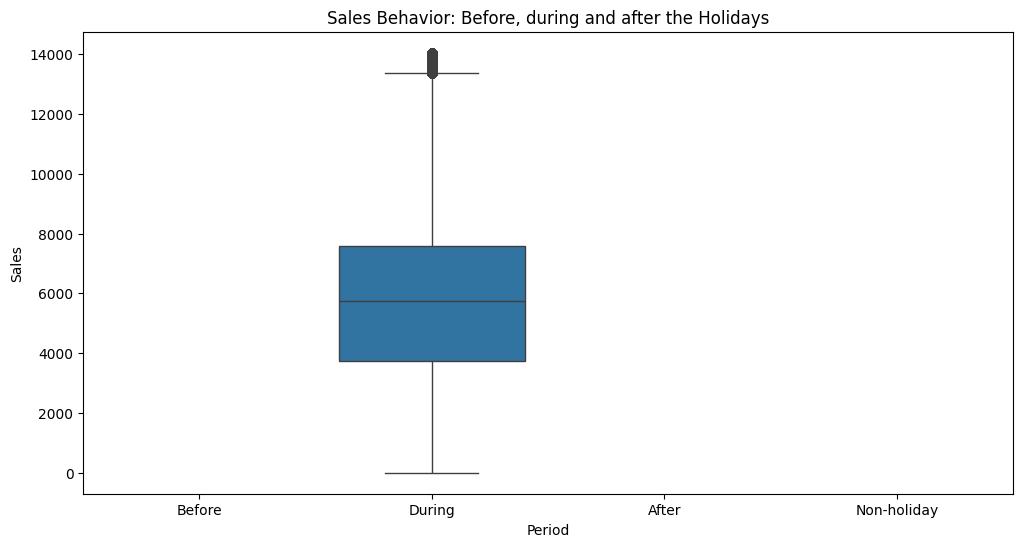

None


In [25]:
from scripts.sales_analysis import visualize_bef_af_hol_sales
sales_bef_aft_hol=visualize_bef_af_hol_sales(train_store)
print(sales_bef_aft_hol)

In [26]:
from scripts.sales_analysis import correlation_matrix
cust_sales= correlation_matrix(train_store)
cust_sales

np.float64(0.8765159262082611)

now we will visualize the correlation between promotion and sales

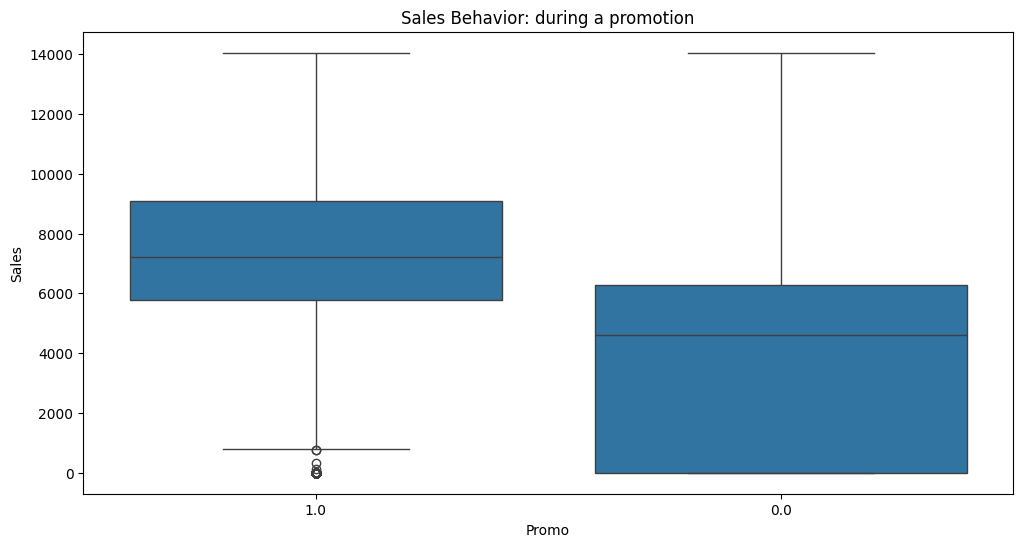

In [29]:
from scripts.sales_analysis import promo_sales
promotion_sales= promo_sales(train_store)
promotion_sales

•	Promotions (1.0) appear to be effective in boosting sales overall, as sales are consistently higher.
•	The presence of outliers during promotions suggests variability in the promotion's impact

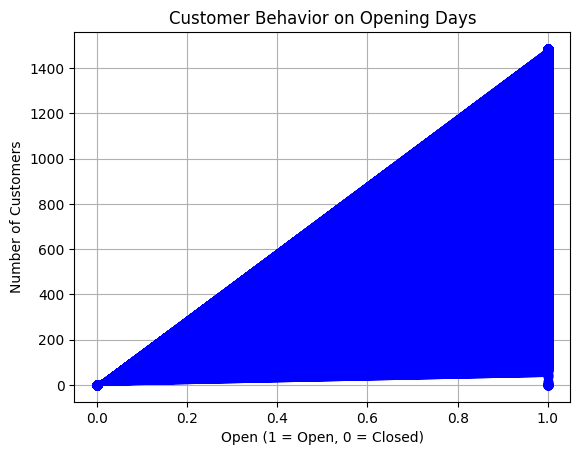

In [48]:
from scripts.sales_analysis import customer_open
opening_cust_beh= customer_open(train_store)
opening_cust_beh 

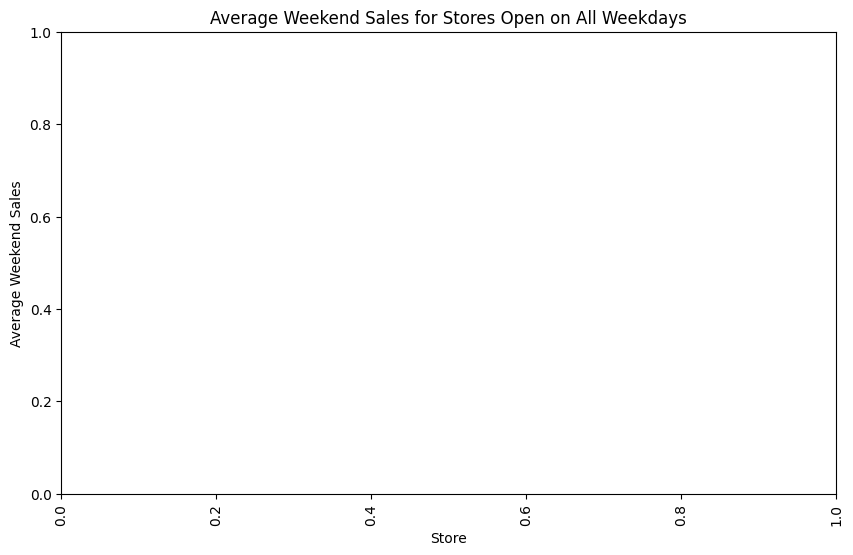

In [41]:
from scripts.sales_analysis import sales_on_weekend
weekend_sales = sales_on_weekend(train_store)
weekend_sales

C:\Users\hp\Desktop\tutorial\kaim-week-4\scripts\sales_analysis.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sales=data.groupby('Competition_dist_group')['Sales'].agg['mean','median','std','count']


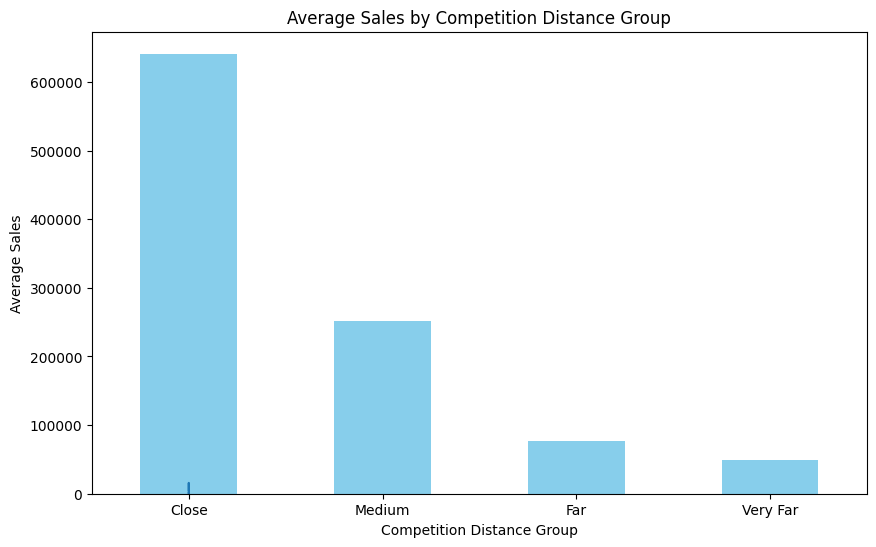

In [63]:
from scripts.sales_analysis import comp_dist_effect
graph_comp_dist_effect=comp_dist_effect(train_store)
graph_comp_dist_effect

Here we see that competitions opened very far off our store have very little effect on our sales compared to close range competitions